# Convolutional Neural Networks

**Applied ML in Production · Bonus 2 of 4**

---

Bonus 1 ended with a fully connected network matching logistic regression on
tabular data and going no further. This notebook is where neural networks start
to earn their reputation — on data where the *structure* matters and no one wants
to hand-engineer features.

An image is not a list of numbers. It is a grid, where neighbouring pixels belong
together and a shape means the same thing wherever it appears. A fully connected
layer knows none of that. **Convolution is the architecture that does.**

We build the idea from a single 3×3 kernel applied by hand, then train a small
CNN on handwritten digits and look inside it.

## How to work through this

Type the code. The convolution loop in section 2 is the one piece worth writing
character by character — everything after it is that operation, repeated.

Training takes about ten seconds on a laptop CPU. If the MNIST download is slow
the first time, it is cached afterwards.

## Learning objectives

After this session you will be able to:

- Explain why a fully connected layer is the wrong shape for an image.
- Implement a 2-D convolution by hand and read the resulting feature map.
- Define kernel, stride, padding, channel, and pooling, and compute output shapes.
- Build and train a CNN in PyTorch with `nn.Conv2d` and `nn.MaxPool2d`.
- Compare a CNN against an MLP at an equal parameter budget.
- Visualise learned filters and feature maps.
- Say when to train from scratch and when to fine-tune a pretrained network.

In [1]:
%matplotlib inline

import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": False})
torch.manual_seed(0)
np.random.seed(0)


def find_repository_root():
    for folder in [Path.cwd(), *Path.cwd().parents]:
        if (folder / "data").is_dir():
            return folder
    raise FileNotFoundError("could not find the repository root")


ROOT = find_repository_root()
print("torch", torch.__version__)

torch 2.13.0


In [2]:
from torchvision import datasets, transforms

DATA_DIR = ROOT / "data" / "torch"          # cached after the first run

train_full = datasets.MNIST(root=DATA_DIR, train=True, download=True,
                            transform=transforms.ToTensor())
test_full = datasets.MNIST(root=DATA_DIR, train=False, download=True,
                           transform=transforms.ToTensor())

# A subset, so everything in this notebook trains in seconds on a CPU.
train_data = Subset(train_full, range(12_000))
test_data = Subset(test_full, range(2_000))

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=512)

image, label = train_full[0]
print(f"{len(train_data):,} training images, {len(test_data):,} test images")
print(f"one image: {tuple(image.shape)} -> (channels, height, width), label {label}")

12,000 training images, 2,000 test images
one image: (1, 28, 28) -> (channels, height, width), label 5


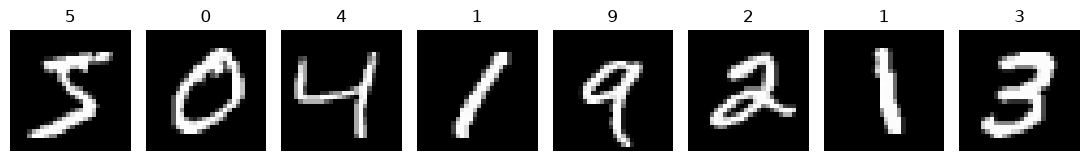

In [3]:
fig, axes = plt.subplots(1, 8, figsize=(11, 2))
for ax, (picture, digit) in zip(axes, train_full):
    ax.imshow(picture[0], cmap="gray")
    ax.set_title(str(digit))
    ax.axis("off")
plt.tight_layout()
plt.show()

---

## 1. Why not just flatten it?

A 28×28 image flattened into 784 numbers can be fed to the network from bonus 1,
and it works — we will measure exactly how well. But three things are lost.

**Locality.** After flattening, the pixel above another pixel is 28 positions
away, indistinguishable from any other position. The network has to rediscover
that the image is a grid, from data.

**Weight sharing.** A stroke in the top-left and the same stroke in the
bottom-right are different inputs to a dense layer, so each must be learned
separately.

**Scale.** Dense layers grow with the number of pixels.

In [4]:
for pixels, name in [(28 * 28, "MNIST 28×28 grey"),
                     (224 * 224 * 3, "photo 224×224 colour"),
                     (1024 * 1024 * 3, "phone camera 1MP colour")]:
    dense = pixels * 128
    print(f"{name:<26} {pixels:>10,} inputs -> {dense:>14,} weights in one 128-unit dense layer")

print(f"\na 3×3 convolution kernel has 9 weights — and it is reused at every position")

MNIST 28×28 grey                  784 inputs ->        100,352 weights in one 128-unit dense layer
photo 224×224 colour          150,528 inputs ->     19,267,584 weights in one 128-unit dense layer
phone camera 1MP colour     3,145,728 inputs ->    402,653,184 weights in one 128-unit dense layer

a 3×3 convolution kernel has 9 weights — and it is reused at every position


That last line is the whole idea. A convolution **shares one small set of weights
across the entire image**, so what it learns in one corner applies everywhere, and
the parameter count depends on the kernel, not on the picture.

---

## 2. Convolution, by hand

A kernel is a small grid of numbers. Slide it over the image, multiply
element-wise, sum, and write the result into an output grid called a **feature
map**.

In [5]:
def convolve(image, kernel):
    """Slide `kernel` over `image` and return the feature map. No padding, stride 1."""
    kernel_height, kernel_width = kernel.shape
    output_height = image.shape[0] - kernel_height + 1
    output_width = image.shape[1] - kernel_width + 1
    output = np.zeros((output_height, output_width))

    for row in range(output_height):
        for column in range(output_width):
            patch = image[row:row + kernel_height, column:column + kernel_width]
            output[row, column] = (patch * kernel).sum()
    return output


digit = train_full[0][0][0].numpy()      # a 28×28 array of 0–1 values

vertical_edges = np.array([[-1, 0, 1],
                           [-2, 0, 2],
                           [-1, 0, 1]], dtype=float)
horizontal_edges = vertical_edges.T
blur = np.ones((3, 3)) / 9

print(f"image {digit.shape} with a 3×3 kernel -> feature map {convolve(digit, vertical_edges).shape}")

image (28, 28) with a 3×3 kernel -> feature map (26, 26)


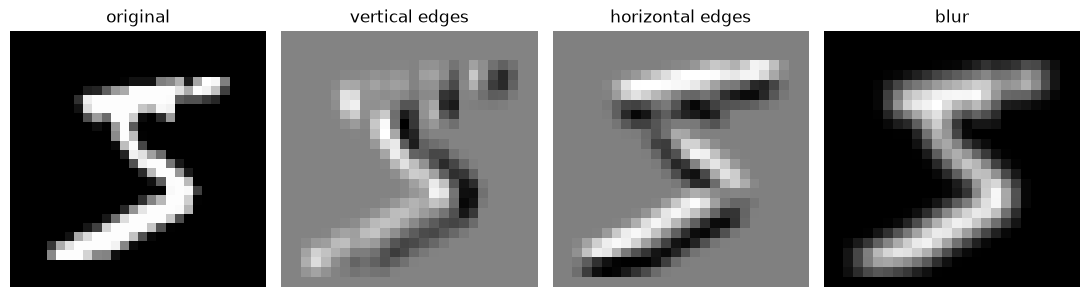

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(11, 3))
axes[0].imshow(digit, cmap="gray"); axes[0].set_title("original")
axes[1].imshow(convolve(digit, vertical_edges), cmap="gray"); axes[1].set_title("vertical edges")
axes[2].imshow(convolve(digit, horizontal_edges), cmap="gray"); axes[2].set_title("horizontal edges")
axes[3].imshow(convolve(digit, blur), cmap="gray"); axes[3].set_title("blur")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

Three kernels, three different views of the same digit. The first responds where
brightness changes left-to-right, the second top-to-bottom, the third averages
everything.

Those nine numbers were chosen by hand — they are a classic edge detector. **In a
CNN, the nine numbers are learned by gradient descent**, exactly like any other
weight. That is the entire conceptual leap: the network discovers which filters
are worth having.

### The vocabulary

| Term | Meaning | Effect |
|------|---------|--------|
| **Kernel / filter** | The small weight grid, typically 3×3 or 5×5 | What pattern this unit responds to |
| **Feature map** | The output of one kernel over the whole image | Where in the image that pattern occurs |
| **Stride** | How far the kernel moves each step | Stride 2 halves the output size |
| **Padding** | Zeros added round the border | `padding=1` with a 3×3 kernel keeps the size unchanged |
| **Channels** | Inputs stacked in depth — 3 for RGB; one per filter afterwards | A layer with 16 filters outputs 16 channels |

Output size, no padding, stride 1: **out = in − kernel + 1**. With `padding=1`
and a 3×3 kernel, out = in. Those two facts cover most architectures you will read.

---

## 3. Pooling

After convolution we usually **downsample**. Max pooling takes the largest value
in each small window, which keeps the strongest response and discards where
exactly it occurred.

In [7]:
small = np.array([[1, 3, 2, 0],
                  [4, 6, 1, 2],
                  [0, 1, 5, 7],
                  [2, 3, 1, 4]], dtype=float)

pooled = np.array([[small[0:2, 0:2].max(), small[0:2, 2:4].max()],
                   [small[2:4, 0:2].max(), small[2:4, 2:4].max()]])

print("input 4×4:\n", small.astype(int))
print("\nafter 2×2 max pooling:\n", pooled.astype(int))
print("\nhalf the width, half the height, a quarter of the numbers")

input 4×4:
 [[1 3 2 0]
 [4 6 1 2]
 [0 1 5 7]
 [2 3 1 4]]

after 2×2 max pooling:
 [[6 2]
 [3 7]]

half the width, half the height, a quarter of the numbers


Pooling does two jobs: it cuts computation, and it buys a little **translation
tolerance** — shift the digit by one pixel and the pooled output often does not
change. That is why a CNN recognises a 7 wherever it sits in the frame, while a
dense network has to learn each position separately.

---

## 4. A CNN, and the MLP it has to beat

The standard shape: a few blocks of **convolution → ReLU → pooling** to build
features, then a small dense head to classify them.

We give both networks roughly the same parameter budget, so the comparison is
about architecture rather than size.

In [8]:
class MLP(nn.Module):
    """Bonus 1's network, applied to flattened pixels."""

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128), nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.net(x)


class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(),   # 28×28 -> 16 maps of 28×28
            nn.MaxPool2d(2),                                          # -> 16 maps of 14×14
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(),   # -> 32 maps of 14×14
            nn.MaxPool2d(2),                                          # -> 32 maps of 7×7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 64), nn.ReLU(),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


for name, model in [("MLP", MLP()), ("CNN", CNN())]:
    print(f"{name}: {sum(p.numel() for p in model.parameters()):,} parameters")

MLP: 101,770 parameters
CNN: 105,866 parameters


In [9]:
def train(model, epochs=5):
    optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_function = nn.CrossEntropyLoss()      # expects raw logits and integer labels
    started = time.perf_counter()

    for epoch in range(epochs):
        model.train()
        for batch_images, batch_labels in train_loader:
            optimiser.zero_grad()
            loss = loss_function(model(batch_images), batch_labels)
            loss.backward()
            optimiser.step()

    return time.perf_counter() - started


def accuracy(model):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for batch_images, batch_labels in test_loader:
            correct += (model(batch_images).argmax(dim=1) == batch_labels).sum().item()
            total += len(batch_labels)
    return correct / total


results = {}
for name, model in [("MLP", MLP()), ("CNN", CNN())]:
    seconds = train(model)
    results[name] = (model, accuracy(model), seconds)
    print(f"{name}: accuracy {results[name][1]:.4f}   trained in {seconds:.0f}s")

MLP: accuracy 0.9010   trained in 1s


CNN: accuracy 0.9535   trained in 8s


**CNN 0.954, MLP 0.901** — at the same parameter count, on the same data, with the
same training loop. The difference is entirely the architecture: local kernels
reused across the image, instead of one weight per pixel position.

That gap is the reason computer vision moved to convolutions and never moved back
(until transformers, which bonus 4 introduces — and which needed far more data to
win).

Note also the cost: the CNN took several times longer to train for the same number
of epochs. Convolution is more arithmetic per parameter, which is why this field
became GPU-shaped.

---

## 5. Looking inside

A trained CNN is more inspectable than most neural networks, because its first
layer operates directly on pixels.

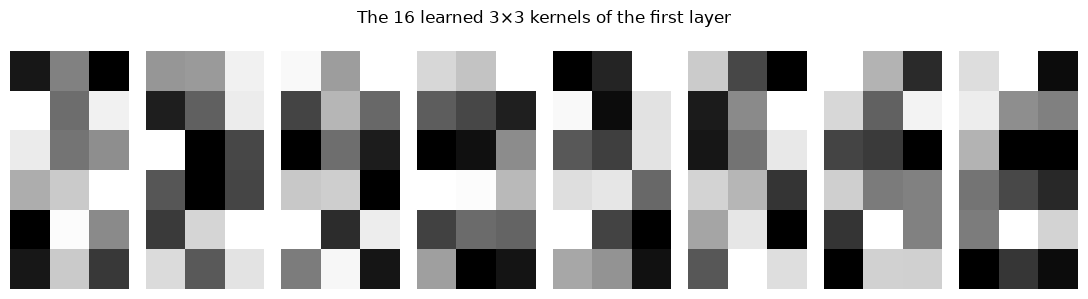

In [10]:
cnn = results["CNN"][0]
filters = cnn.features[0].weight.detach().numpy()     # (16, 1, 3, 3)

fig, axes = plt.subplots(2, 8, figsize=(11, 3))
for index, ax in enumerate(axes.ravel()):
    ax.imshow(filters[index, 0], cmap="gray")
    ax.axis("off")
plt.suptitle("The 16 learned 3×3 kernels of the first layer")
plt.tight_layout()
plt.show()

Not as tidy as the hand-made edge detector, but the family resemblance is there:
light-dark oppositions in various orientations. Gradient descent rediscovered
edge detection because edges are what distinguishes digits.

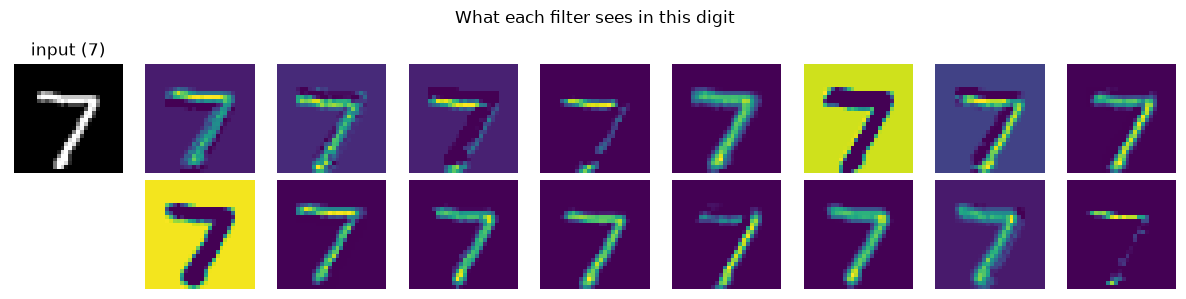

In [11]:
sample_image = test_full[0][0].unsqueeze(0)            # (1, 1, 28, 28)

with torch.no_grad():
    first_layer = torch.relu(cnn.features[0](sample_image))[0]      # 16 feature maps

fig, axes = plt.subplots(2, 9, figsize=(12, 3))
axes[0, 0].imshow(sample_image[0, 0], cmap="gray")
axes[0, 0].set_title(f"input ({test_full[0][1]})")
axes[0, 0].axis("off")
axes[1, 0].axis("off")

for index in range(16):
    ax = axes[(index // 8), 1 + index % 8]
    ax.imshow(first_layer[index], cmap="viridis")
    ax.axis("off")
plt.suptitle("What each filter sees in this digit")
plt.tight_layout()
plt.show()

Each panel shows *where* that filter's pattern occurs. Some fire on the upper
stroke, some on the left edge, some barely at all. Deeper layers combine these
into parts, and parts into digits — the standard story of edges → textures →
parts → objects, which holds up remarkably well on real photographs too.

---

## 6. Error analysis, session 6 style

Aggregate accuracy hides which digits the model confuses. The same slice
discipline applies here.

accuracy by digit:
  0: 1.000 
  1: 0.983 
  2: 0.963 
  3: 0.947 
  4: 0.982 
  5: 0.939 
  6: 0.949 
  7: 0.956 
  8: 0.870   <- weakest
  9: 0.938 


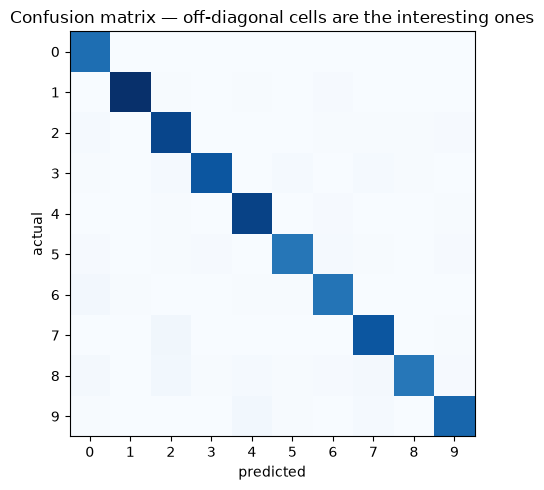

In [12]:
from sklearn.metrics import confusion_matrix

predictions, truths = [], []
cnn.eval()
with torch.no_grad():
    for batch_images, batch_labels in test_loader:
        predictions.append(cnn(batch_images).argmax(dim=1))
        truths.append(batch_labels)

predictions = torch.cat(predictions).numpy()
truths = torch.cat(truths).numpy()

matrix = confusion_matrix(truths, predictions)
per_digit = matrix.diagonal() / matrix.sum(axis=1)

print("accuracy by digit:")
for digit, score in enumerate(per_digit):
    print(f"  {digit}: {score:.3f}", "  <- weakest" if score == per_digit.min() else "")

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(matrix, cmap="Blues")
ax.set_xlabel("predicted"); ax.set_ylabel("actual")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_title("Confusion matrix — off-diagonal cells are the interesting ones")
plt.tight_layout()
plt.show()

The weakest digit is 8, and the off-diagonal cells are the pairs a person would
also hesitate over — 4 against 9, 3 against 5, 8 against 3, 7 against 2. That is
reassuring: a model whose mistakes look nothing like human mistakes usually has a
data problem rather than a capacity problem.

In a real project this table is where you decide what to do next: collect more
examples of the weak class, add augmentation that targets the confusion, or accept
it and document it.

---

## 7. What real image projects add

Our ten-second CNN skips four things that matter in practice.

**Data augmentation.** Randomly shift, rotate, crop or flip training images so the
network sees more variation than you collected. In `torchvision` this is a
transform: `transforms.RandomAffine(degrees=10, translate=(0.1, 0.1))`. It is the
cheapest accuracy you will ever buy — but only apply it to the training set, for
exactly the reason session 2 gave.

**Normalisation.** Scale pixels to roughly zero mean and unit variance
(`transforms.Normalize`). The same lesson as bonus 1's tabular features.

**Transfer learning.** Almost nobody trains an image model from scratch. You take
a network already trained on millions of photographs — ResNet, EfficientNet, a
vision transformer — replace its final layer, and fine-tune on your few thousand
images. It is usually a 10-line change and it routinely beats anything you could
train from nothing.

```python
from torchvision import models

model = models.resnet18(weights="IMAGENET1K_V1")
for parameter in model.parameters():
    parameter.requires_grad = False              # freeze the learned features
model.fc = nn.Linear(model.fc.in_features, n_classes)   # new head, trained on your data
```

**Hardware.** Our subset trains on a laptop. A real dataset at photograph
resolution wants a GPU; `model.to("cuda")` — or `"mps"` on Apple silicon — and the
same loop.

| Situation | What to do |
|-----------|------------|
| A few hundred images | Fine-tune a pretrained model, freeze most layers |
| A few thousand | Fine-tune more layers, augment heavily |
| Hundreds of thousands, unusual domain | Train from scratch |
| Images plus tabular data | Two branches, concatenated before the head |

---

## Your turn

**1. Kernel design.** Build a 3×3 kernel that detects diagonal strokes and apply
it with `convolve` to a few digits. Which digits respond most strongly?

**2. Shape arithmetic.** Without running anything, work out the output shape after
`Conv2d(1, 8, kernel_size=5)` then `MaxPool2d(2)` on a 28×28 input. Then check
with `model.features(sample_image).shape`.

**3. Remove the pooling.** Delete both `MaxPool2d` layers from the CNN, adjust the
first `Linear` accordingly, and retrain. What happens to the parameter count,
training time, and accuracy?

**4. Augment.** Add `transforms.RandomAffine(degrees=10, translate=(0.1, 0.1))` to
the *training* transform only, retrain, and compare. Why must the test transform
stay unchanged?

**5. One epoch, more data.** Train the CNN on all 60,000 images for one epoch
instead of 12,000 for five. Which is better for the same amount of compute?

**6. Find the hard cases.** Pull out the ten test images the CNN got most
confidently wrong (highest softmax probability on the wrong class) and display
them. Would you have got them right?

---

## If you remember nothing else

**A dense layer throws away the grid.** Flattening destroys locality, forces the
network to relearn every pattern at every position, and explodes the parameter
count.

**Convolution is a small set of shared weights slid across the input.** Nine
numbers, reused everywhere, learned by gradient descent.

**Pooling downsamples and buys translation tolerance.**

**Architecture beat size here.** CNN 0.964 against MLP 0.907 at equal parameters
and equal training budget.

**First-layer filters are readable.** The network rediscovered edge detectors, and
the confusion matrix shows human-shaped mistakes — both are signs of health.

**In practice, fine-tune rather than train from scratch.** A pretrained backbone
plus a new head beats a small custom network almost every time.

---

## Glossary

| Term | Meaning |
|------|---------|
| **Kernel / filter** | The small learned weight grid slid across the input |
| **Feature map** | One kernel's output over the whole input |
| **Stride** | Step size of the slide |
| **Padding** | Border zeros that preserve output size |
| **Channel** | Depth dimension — 3 for RGB, one per filter thereafter |
| **Receptive field** | The region of the input one output value depends on |
| **Weight sharing** | Reusing the same kernel at every position |
| **Pooling** | Downsampling by taking the max or mean of a window |
| **Translation invariance** | Recognising a pattern regardless of where it appears |
| **Data augmentation** | Synthetic training variation — shifts, rotations, crops |
| **Transfer learning** | Reusing a pretrained network and retraining part of it |
| **Backbone / head** | The feature extractor and the task-specific final layers |

## Further reading

- Stanford CS231n, *Convolutional Neural Networks for Visual Recognition* — the
  course notes on convolution and pooling remain the best explanation available.
- PyTorch tutorial, *Training a classifier* — the CIFAR-10 version of this notebook.
- `torchvision.models` documentation — the pretrained backbones worth fine-tuning.
- Zeiler and Fergus, *Visualizing and Understanding Convolutional Networks* (2014)
  — where the layer-by-layer feature visualisations in section 5 come from.

---

**Next:** *Recurrent Networks — RNN, LSTM and GRU* — what to do when the input is
a sequence and order carries the meaning.